# Module 10: Sentiment Analysis of Novels

## Moby Dick vs. Persuasion

* DS 5001
* Clay Harris: jbm2rt

# Set Up

In [1]:
lib_csv = 'LIB.xls'
token_csv = 'TOKEN2.xls'
salex_csv = 'salex_nrc.csv'

OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
CHAPS = OHCO[1:2]
PARAS = OHCO[1:3]
SENTS = OHCO[1:4]

moby_dick_id = 2701
persuasion_id = 105

emo = 'polarity'

## Import

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.core.display import display, HTML

/var/folders/fn/36dz4z514cd0cmgsz1j3_f340000gn/T/ipykernel_64013/2767818369.py:4: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [3]:
sns.set()
%matplotlib inline

## Get Lexicon

In [4]:
salex = pd.read_csv(salex_csv).set_index('term_str')
salex.columns = [col.replace('nrc_','') for col in salex.columns]

In [5]:
salex['polarity'] = salex.positive - salex.negative

## Get Lexicon Columns

In [6]:
emo_cols = "anger anticipation disgust fear joy sadness surprise trust polarity".split()
emo_cols

['anger',
 'anticipation',
 'disgust',
 'fear',
 'joy',
 'sadness',
 'surprise',
 'trust',
 'polarity']

# Get Novels

Join TOKEN2 with LIB on `book_id` to get book names, then filter for Moby Dick and Persuasion.

In [7]:
LIB = pd.read_csv(lib_csv)
LIB[['book_id', 'title', 'author']]

,book_id,title,author
0,158,Emma,austen
1,946,Lady Susan,austen
2,1212,Love And Freindship And Other Early Works,austen
3,141,Mansfield Park,austen
4,121,Northanger Abbey,austen
5,105,Persuasion,austen
6,1342,Pride and Prejudice,austen
7,161,Sense and Sensibility,austen
8,15422,Israel Potter,melville
9,13720,"Mardi: and A Voyage Thither, Vol. I (of 2)",melville


In [8]:
TOKEN2 = pd.read_csv(token_csv)
TOKEN2.head()

,book_id,chap_num,para_num,sent_num,token_num,pos_tuple,pos,token_str,term_str,term_id
0,158,1,1,0,0,"('Emma', 'NNP')",NNP,Emma,emma,11614
1,158,1,1,0,1,"('Woodhouse', 'NNP')",NNP,Woodhouse,woodhouse,39340
2,158,1,1,0,3,"('handsome', 'NN')",NN,handsome,handsome,15924
3,158,1,1,0,5,"('clever', 'NN')",NN,clever,clever,6354
4,158,1,1,0,7,"('and', 'CC')",CC,and,and,1426


## Join TOKEN2 with LIB to get book names

In [9]:
TOKENS = TOKEN2.merge(LIB[['book_id', 'title']], on='book_id', how='left')
TOKENS.rename(columns={'title': 'book'}, inplace=True)
TOKENS.head()

,book_id,chap_num,para_num,sent_num,token_num,pos_tuple,pos,token_str,term_str,term_id,book
0,158,1,1,0,0,"('Emma', 'NNP')",NNP,Emma,emma,11614,Emma
1,158,1,1,0,1,"('Woodhouse', 'NNP')",NNP,Woodhouse,woodhouse,39340,Emma
2,158,1,1,0,3,"('handsome', 'NN')",NN,handsome,handsome,15924,Emma
3,158,1,1,0,5,"('clever', 'NN')",NN,clever,clever,6354,Emma
4,158,1,1,0,7,"('and', 'CC')",CC,and,and,1426,Emma


## Filter for Moby Dick and Persuasion

In [10]:
TOKENS = TOKENS[TOKENS.book_id.isin([moby_dick_id, persuasion_id])].copy()
TOKENS = TOKENS.set_index(OHCO).sort_index()
TOKENS.head()

pos_tuple  pos  \
book_id chap_num para_num sent_num token_num                             
105     1        1        0        0               ('Sir', 'NNP')  NNP   
                                   1            ('Walter', 'NNP')  NNP   
                                   2            ('Elliot', 'NNP')  NNP   
                                   4                 ('of', 'IN')   IN   
                                   5          ('Kellynch', 'NNP')  NNP   

                                             token_str  term_str  term_id  \
book_id chap_num para_num sent_num token_num                                
105     1        1        0        0               Sir       sir    31573   
                                   1            Walter    walter    38510   
                                   2            Elliot    elliot    11468   
                                   4                of        of    23891   
                                   5          Kellynch  kellynch    19515   

                                                    book  
book_id chap_num para_num sent_num token_num              
105     1        1        0        0          Persuasion  
                                   1          Persuasion  
                                   2          Persuasion  
                                   4          Persuasion  
                                   5          Persuasion

## Join with NRC Sentiment Lexicon

In [11]:
TOKENS = TOKENS.join(salex, on='term_str', how='left')
TOKENS[emo_cols] = TOKENS[emo_cols].fillna(0)

In [12]:
TOKENS[['term_str'] + emo_cols].sample(10)

term_str  anger  anticipation  \
book_id chap_num para_num sent_num token_num                                 
2701    138      67       0        2          chanced    0.0           0.0   
105     22       48       5        9              and    0.0           0.0   
2701    57       29       0        78           shade    0.0           0.0   
105     10       46       4        6             both    0.0           0.0   
2701    75       19       0        4               go    0.0           0.0   
        47       9        4        20             the    0.0           0.0   
        138      3        7        28            that    0.0           0.0   
        56       9        10       35             the    0.0           0.0   
        32       10       11       28         tumbled    0.0           0.0   
105     8        3        0        2               no    0.0           0.0   

                                              disgust  fear  joy  sadness  \
book_id chap_num para_num sent_num token_num                                
2701    138      67       0        2              0.0   0.0  0.0      0.0   
105     22       48       5        9              0.0   0.0  0.0      0.0   
2701    57       29       0        78             0.0   0.0  0.0      0.0   
105     10       46       4        6              0.0   0.0  0.0      0.0   
2701    75       19       0        4              0.0   0.0  0.0      0.0   
        47       9        4        20             0.0   0.0  0.0      0.0   
        138      3        7        28             0.0   0.0  0.0      0.0   
        56       9        10       35             0.0   0.0  0.0      0.0   
        32       10       11       28             0.0   0.0  0.0      0.0   
105     8        3        0        2              0.0   0.0  0.0      0.0   

                                              surprise  trust  polarity  
book_id chap_num para_num sent_num token_num                             
2701    138      67       0        2               0.0    0.0       0.0  
105     22       48       5        9               0.0    0.0       0.0  
2701    57       29       0        78              0.0    0.0       0.0  
105     10       46       4        6               0.0    0.0       0.0  
2701    75       19       0        4               0.0    0.0       0.0  
        47       9        4        20              0.0    0.0       0.0  
        138      3        7        28              0.0    0.0       0.0  
        56       9        10       35              0.0    0.0       0.0  
        32       10       11       28              0.0    0.0       0.0  
105     8        3        0        2               0.0    0.0       0.0

In [13]:
TOKENS.head()

pos_tuple  pos  \
book_id chap_num para_num sent_num token_num                             
105     1        1        0        0               ('Sir', 'NNP')  NNP   
                                   1            ('Walter', 'NNP')  NNP   
                                   2            ('Elliot', 'NNP')  NNP   
                                   4                 ('of', 'IN')   IN   
                                   5          ('Kellynch', 'NNP')  NNP   

                                             token_str  term_str  term_id  \
book_id chap_num para_num sent_num token_num                                
105     1        1        0        0               Sir       sir    31573   
                                   1            Walter    walter    38510   
                                   2            Elliot    elliot    11468   
                                   4                of        of    23891   
                                   5          Kellynch  kellynch    19515   

                                                    book  anger  anticipation  \
book_id chap_num para_num sent_num token_num                                    
105     1        1        0        0          Persuasion    0.0           0.0   
                                   1          Persuasion    0.0           0.0   
                                   2          Persuasion    0.0           0.0   
                                   4          Persuasion    0.0           0.0   
                                   5          Persuasion    0.0           0.0   

                                              disgust  fear  joy  negative  \
book_id chap_num para_num sent_num token_num                                 
105     1        1        0        0              0.0   0.0  0.0       0.0   
                                   1              0.0   0.0  0.0       NaN   
                                   2              0.0   0.0  0.0       NaN   
                                   4              0.0   0.0  0.0       NaN   
                                   5              0.0   0.0  0.0       NaN   

                                              positive  sadness  surprise  \
book_id chap_num para_num sent_num token_num                                
105     1        1        0        0               1.0      0.0       0.0   
                                   1               NaN      0.0       0.0   
                                   2               NaN      0.0       0.0   
                                   4               NaN      0.0       0.0   
                                   5               NaN      0.0       0.0   

                                              trust  polarity  
book_id chap_num para_num sent_num token_num                   
105     1        1        0        0            1.0       1.0  
                                   1            0.0       0.0  
                                   2            0.0       0.0  
                                   4            0.0       0.0  
                                   5            0.0       0.0

## Separate Novels

In [14]:
MOBYDICK = TOKENS.loc[moby_dick_id].copy()
PERSUASION = TOKENS.loc[persuasion_id].copy()

## Mean Sentiment Bar Charts

<Axes: title={'center': 'Moby Dick - Mean Sentiment'}>

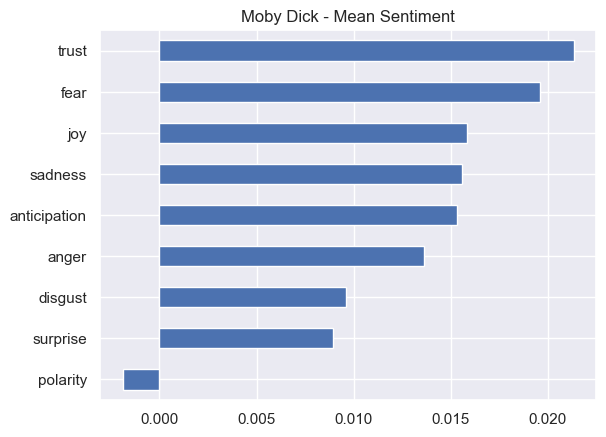

In [15]:
MOBYDICK[emo_cols].mean().sort_values().plot.barh(title='Moby Dick - Mean Sentiment')

<Axes: title={'center': 'Persuasion - Mean Sentiment'}>

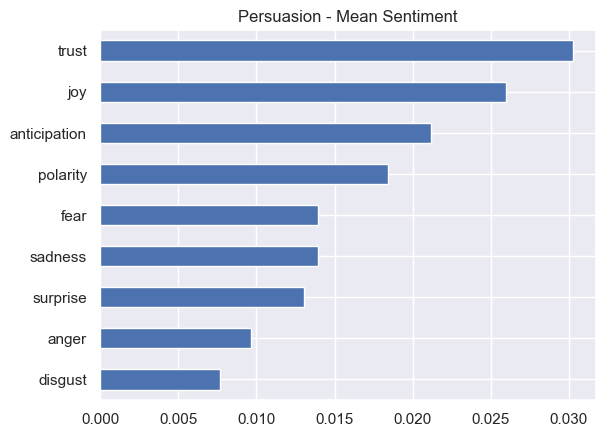

In [16]:
PERSUASION[emo_cols].mean().sort_values().plot.barh(title='Persuasion - Mean Sentiment')

# Sentiment by Chapter

In [17]:
MOBYDICK_chaps = MOBYDICK.groupby(CHAPS)[emo_cols].mean()
PERSUASION_chaps = PERSUASION.groupby(CHAPS)[emo_cols].mean()

In [18]:
def plot_sentiments(df, emo='polarity'):
    FIG = dict(figsize=(25, 5), legend=True, fontsize=14, rot=45)
    df[emo].plot(**FIG)

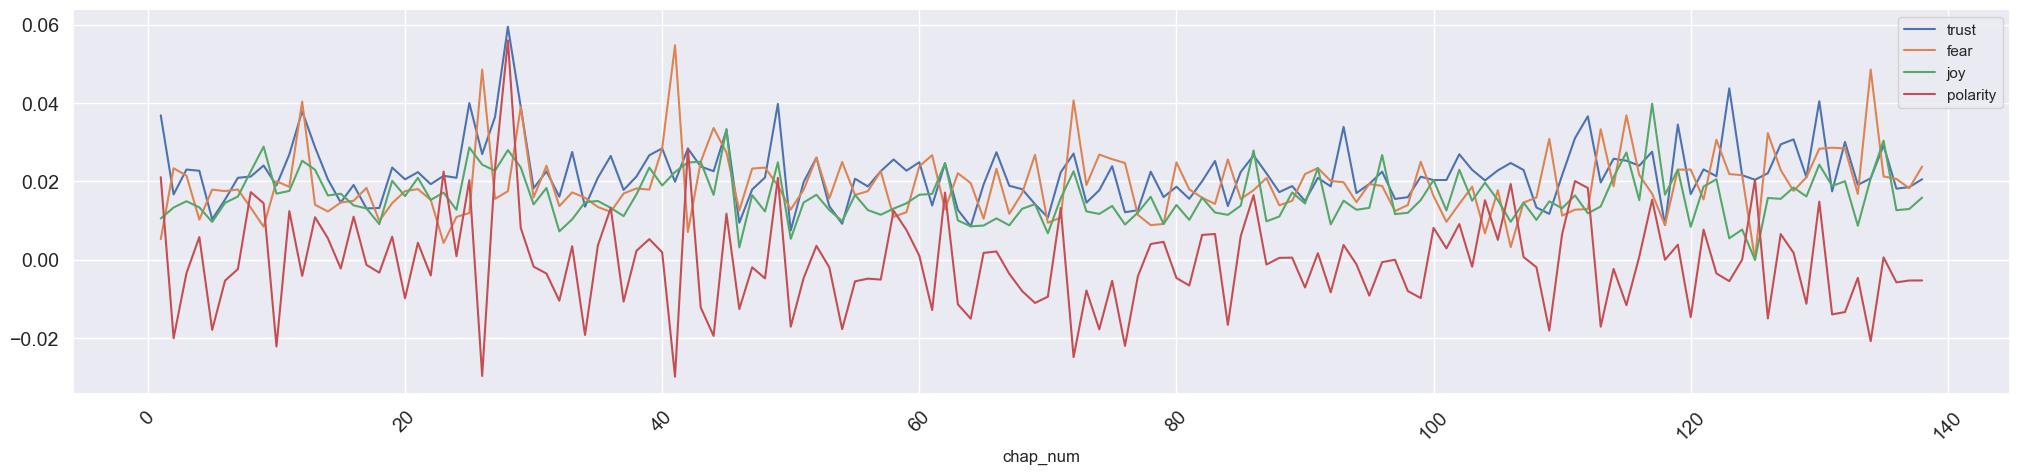

In [19]:
plot_sentiments(MOBYDICK_chaps, ['trust','fear','joy','polarity'])

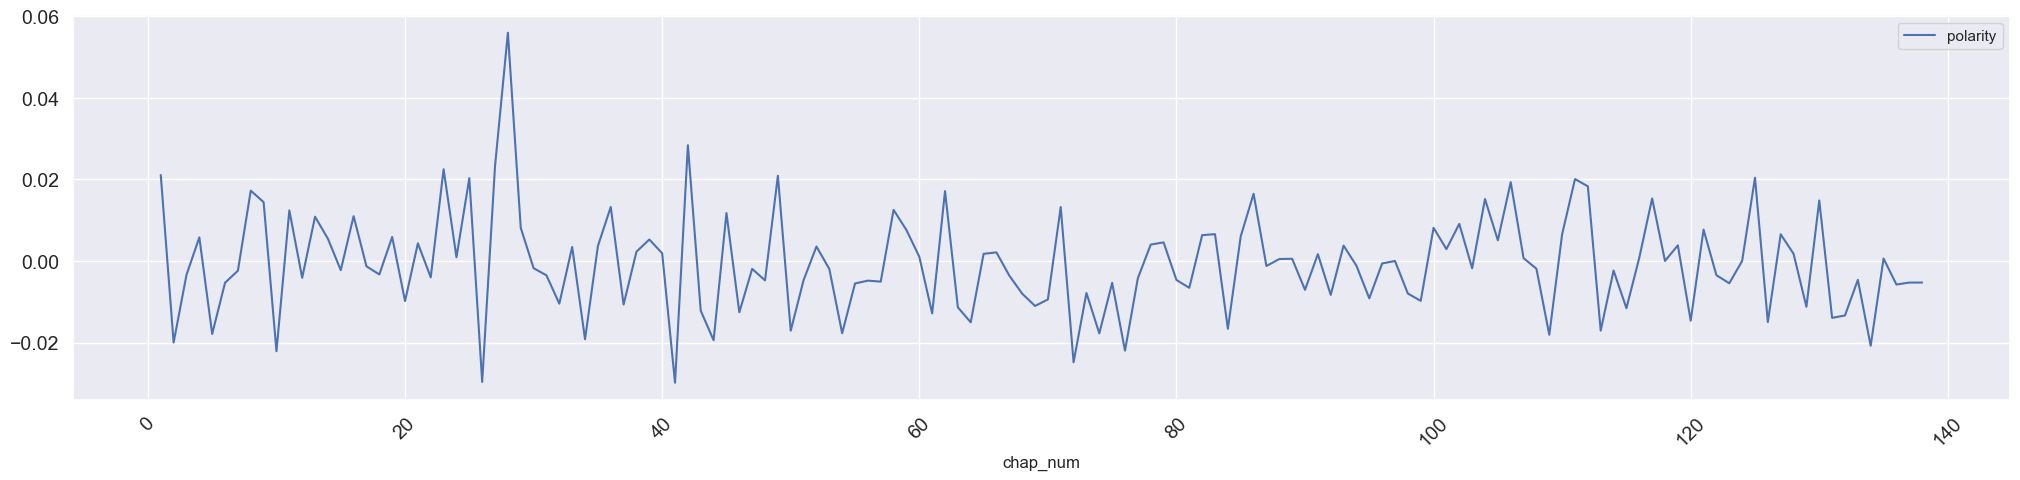

In [20]:
plot_sentiments(MOBYDICK_chaps, ['polarity'])

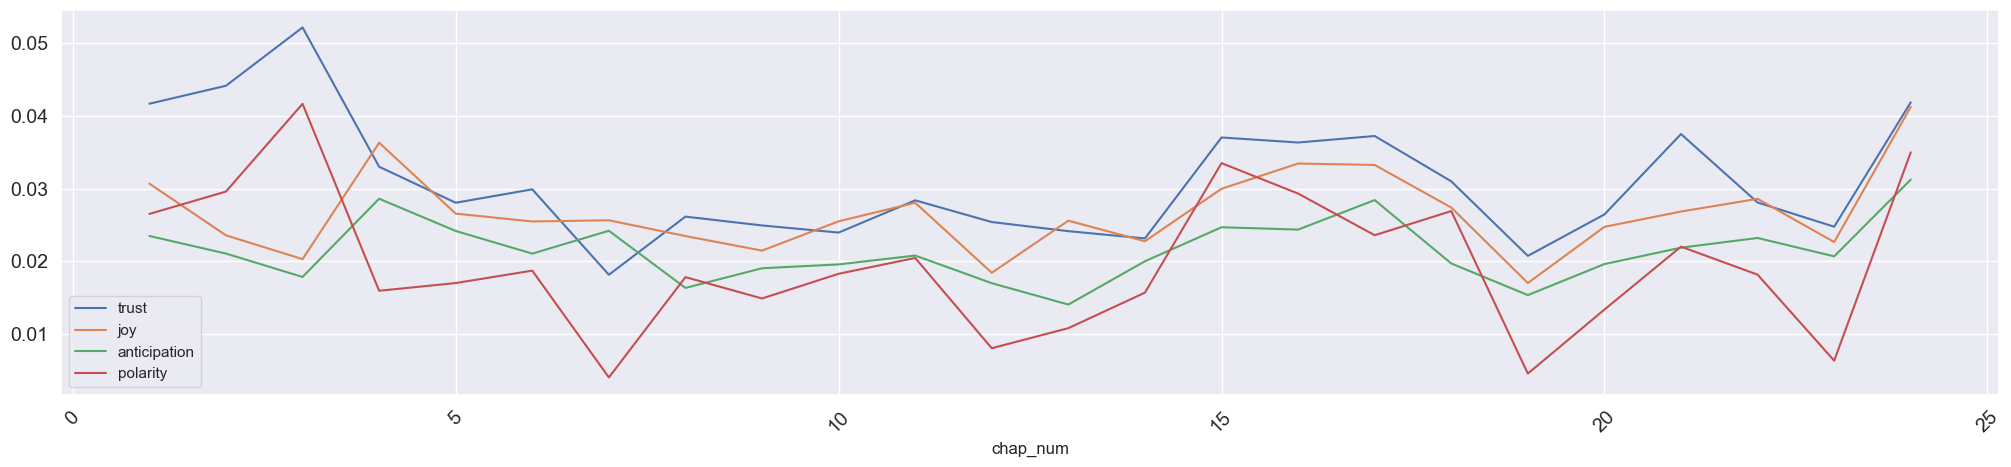

In [21]:
plot_sentiments(PERSUASION_chaps, ['trust','joy','anticipation','polarity'])

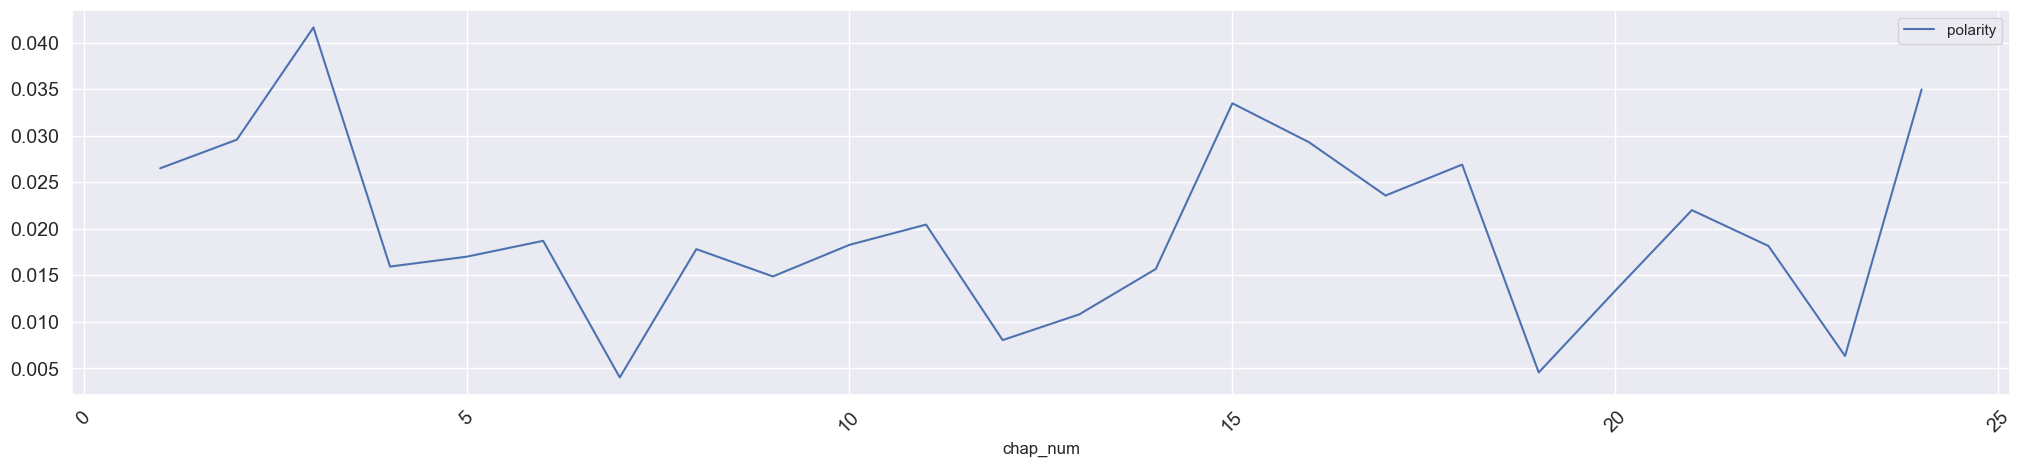

In [22]:
plot_sentiments(PERSUASION_chaps, ['polarity'])

# Explore Sentiment in Texts

In [23]:
MOBYDICK['html'] = MOBYDICK.apply(lambda x: "<span class='sent{}'>{}</span>".format(int(np.sign(x[emo])), x.token_str), 1)
PERSUASION['html'] = PERSUASION.apply(lambda x: "<span class='sent{}'>{}</span>".format(int(np.sign(x[emo])), x.token_str), 1)

In [24]:
MOBYDICK['html'].sample(10)

chap_num  para_num  sent_num  token_num
43        47        0         2              <span class='sent0'>VOICE</span>
136       47        0         2                <span class='sent0'>n't</span>
68        3         0         0                <span class='sent0'>The</span>
74        5         1         38               <span class='sent0'>sea</span>
57        58        0         77                <span class='sent0'>go</span>
103       24        8         0                <span class='sent0'>You</span>
121       6         0         11                <span class='sent0'>'s</span>
6         9         2         0             <span class='sent0'>Supper</span>
24        26        4         0            <span class='sent0'>Besides</span>
43        49        14        6                <span class='sent0'>yet</span>
Name: html, dtype: object

In [25]:
MOBYDICK_sents = MOBYDICK.groupby(SENTS)[emo_cols].mean()
PERSUASION_sents = PERSUASION.groupby(SENTS)[emo_cols].mean()

In [26]:
MOBYDICK_sents['sent_str'] = MOBYDICK.groupby(SENTS).term_str.apply(lambda x: x.str.cat(sep=' '))
MOBYDICK_sents['html_str'] = MOBYDICK.groupby(SENTS).html.apply(lambda x: x.str.cat(sep=' '))

In [27]:
PERSUASION_sents['sent_str'] = PERSUASION.groupby(SENTS).term_str.apply(lambda x: x.str.cat(sep=' '))
PERSUASION_sents['html_str'] = PERSUASION.groupby(SENTS).html.apply(lambda x: x.str.cat(sep=' '))

In [28]:
def sample_sentences(df):
    rows = []
    for idx in df.sample(10).index:
        valence = round(df.loc[idx, emo], 4)
        t = 0
        if valence > t: color = '#ccffcc'
        elif valence < t: color = '#ffcccc'
        else: color = '#f2f2f2'
        rows.append("""<tr style="background-color:{0};padding:.5rem 1rem;font-size:110%;">
        <td>{1}</td><td>{3}</td><td width="400" style="text-align:left;">{2}</td>
        </tr>""".format(color, valence, df.loc[idx, 'html_str'], idx))

    display(HTML('<style>#sample1 td{font-size:120%;vertical-align:top;} .sent-1{color:red;font-weight:bold;} .sent1{color:green;font-weight:bold;}</style>'))
    display(HTML('<table id="sample1"><tr><th>Sentiment</th><th>ID</th><th width="600">Sentence</th></tr>'+''.join(rows)+'</table>'))

In [29]:
sample_sentences(MOBYDICK_sents)

Sentiment,ID,Sentence
0.0,"(127, 3, 0)",Ha ha my ship
0.0,"(128, 15, 1)",The loose coils rapidly straightened out in a long dragging line astern and then instantly the reel began to whirl
0.1429,"(130, 19, 0)",I was about to say sir that
-0.0169,"(14, 3, 0)",We had been sitting in this crouching manner for some time when all at once I thought I would open my eyes for when between sheets whether by day or by night and whether asleep or awake I have a way of always keeping my eyes shut in order the more to concentrate the snugness of being in bed
0.0,"(16, 14, 9)",The greenhorn had gone down
0.0392,"(117, 1, 1)",Often in mild pleasant weather for twelve fifteen eighteen and twenty hours on the stretch they were engaged in the boats steadily pulling or sailing or paddling after the whales or for an interlude of sixty or seventy minutes calmly awaiting their uprising though with but small success for their pains
-0.125,"(20, 10, 6)",it will be the ruin of my house
0.0,"(3, 78, 1)",DARWIN 'S VOYAGE OF A NATURALIST
-0.1429,"(10, 2, 4)",A muffled silence reigned only broken at times by the shrieks of the storm
-0.125,"(64, 14, 3)",yelled Daggoo straining forwards and backwards on his seat like a pacing tiger in his cage


In [30]:
sample_sentences(PERSUASION_sents)

Sentiment,ID,Sentence
-0.1429,"(20, 47, 8)",Could there have been any unpleasant glances
0.0714,"(6, 1, 3)",or in the anxious supplement from Mary of Upon my word I shall be pretty well off when you are all gone away to be happy at Bath
-0.0303,"(13, 11, 1)",The subjects of which her heart had been full on leaving Kellynch and which she had felt slighted and been compelled to smother among the Musgroves were now become but of secondary interest
-0.0833,"(10, 44, 3)",If it were war now he would have settled it long ago
-0.1429,"(10, 30, 0)",Do you mean that she refused him
0.0,"(12, 39, 0)",A surgeon
0.0,"(20, 47, 0)",Such was her situation with a vacant space at hand when Captain Wentworth was again in sight
0.2,"(1, 18, 0)",Sir Walter had resented it
0.0526,"(12, 53, 0)",That he did not regard it as a desperate case that he did not say a few hours must end it was at first felt beyond the hope of most and the ecstasy of such a reprieve the rejoicing deep and silent after a few fervent ejaculations of gratitude to Heaven had been offered may be conceived
-0.0169,"(14, 33, 1)",When Lady Russell not long afterwards was entering Bath on a wet afternoon and driving through the long course of streets from the Old Bridge to Camden Place amidst the dash of other carriages the heavy rumble of carts and drays the bawling of newspapermen muffin men and milkmen and the ceaseless clink of pattens she made no complaint


# VADER

In [31]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyser = SentimentIntensityAnalyzer()

In [32]:
MOBYDICK_vader_cols = MOBYDICK_sents.sent_str.apply(analyser.polarity_scores).apply(lambda x: pd.Series(x))
MOBYDICK_vader = pd.concat([MOBYDICK_sents, MOBYDICK_vader_cols], axis=1)

<Axes: title={'center': 'Moby Dick - VADER compound'}, xlabel='chap_num,para_num,sent_num'>

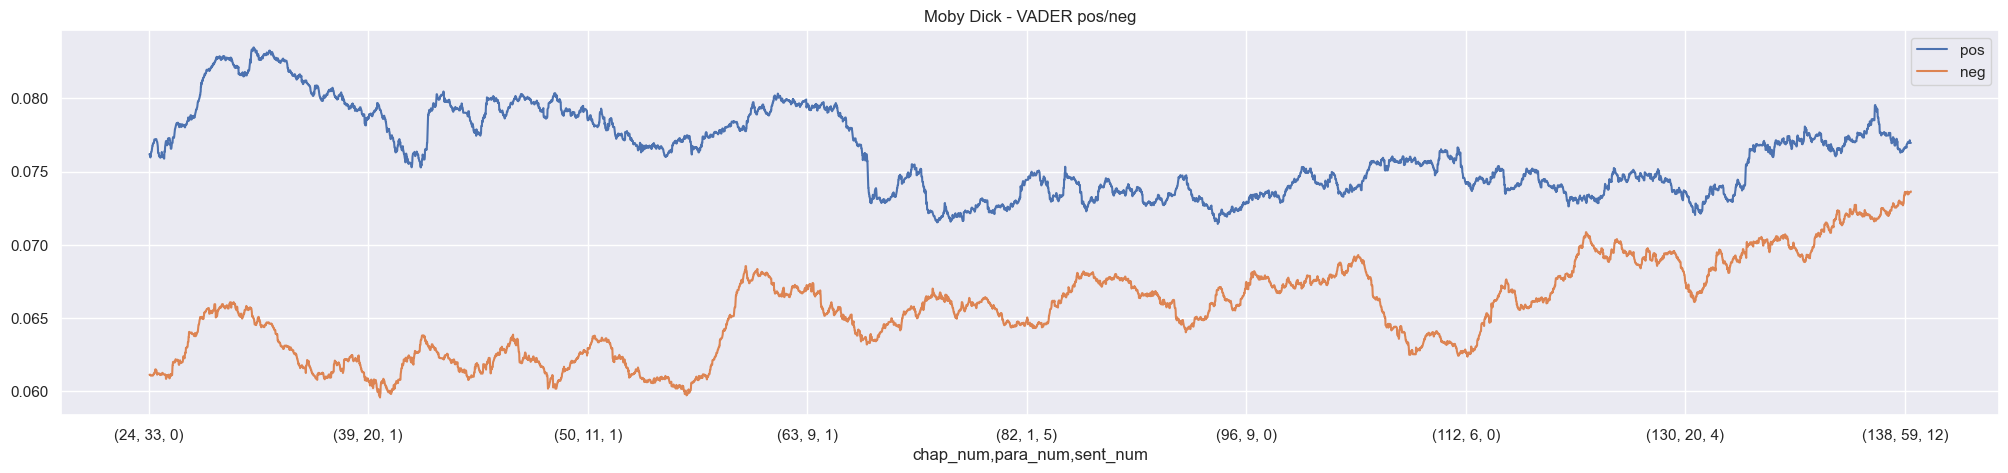

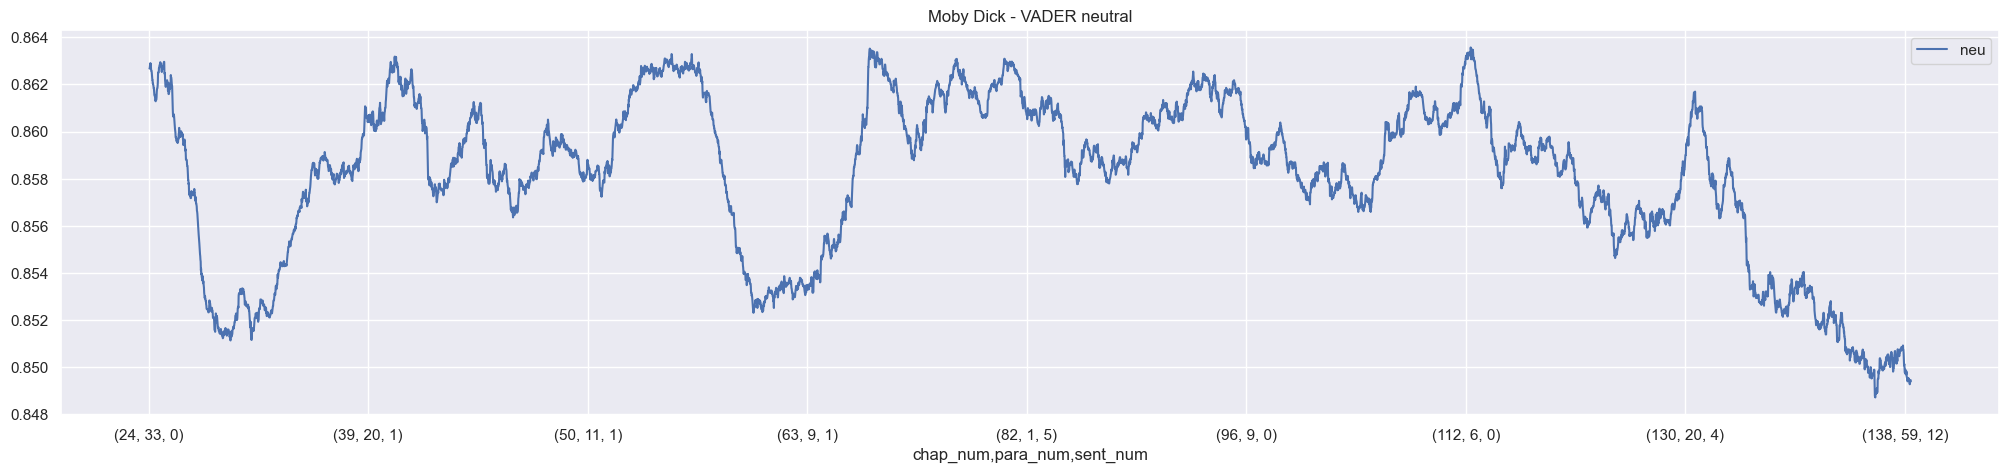

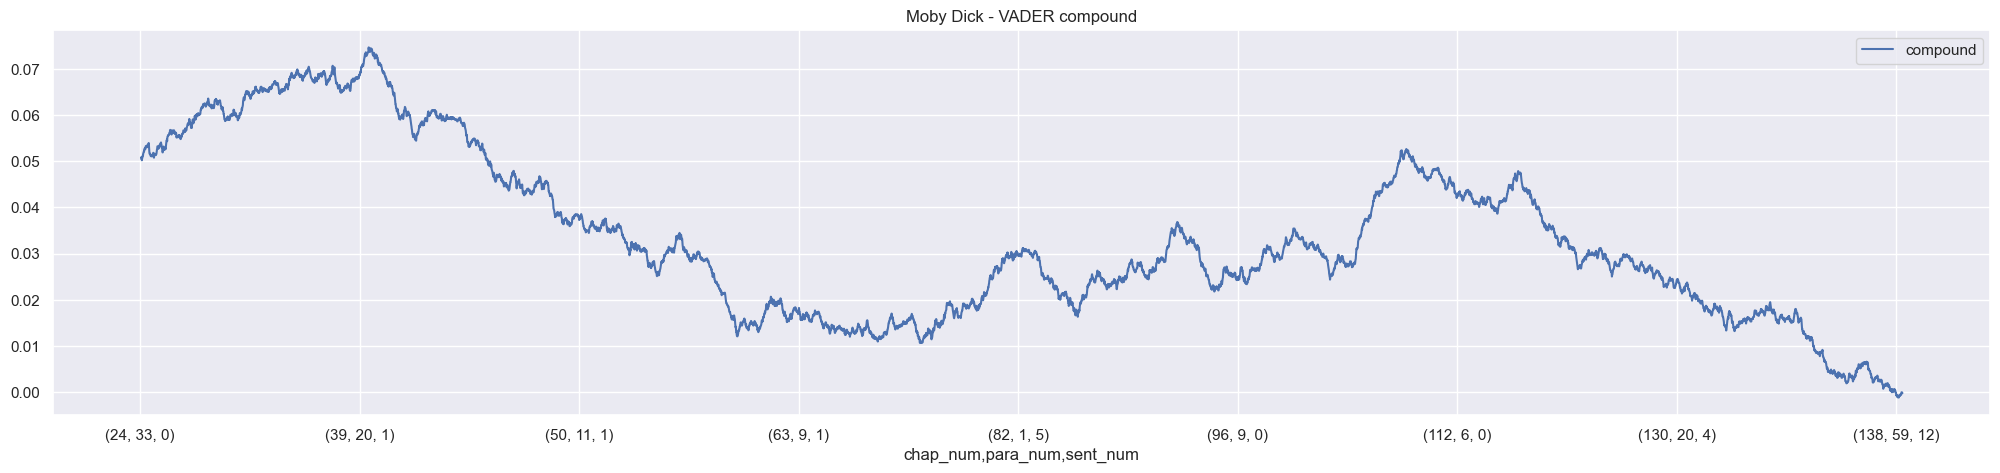

In [33]:
w = int(MOBYDICK_vader.shape[0] / 5)
MOBYDICK_vader[['pos','neg']].rolling(w).mean().plot(figsize=(25,5), title='Moby Dick - VADER pos/neg')
MOBYDICK_vader[['neu']].rolling(w).mean().plot(figsize=(25,5), title='Moby Dick - VADER neutral')
MOBYDICK_vader[['compound']].rolling(w).mean().plot(figsize=(25,5), title='Moby Dick - VADER compound')

In [34]:
PERSUASION_vader_cols = PERSUASION_sents.sent_str.apply(analyser.polarity_scores).apply(lambda x: pd.Series(x))
PERSUASION_vader = pd.concat([PERSUASION_sents, PERSUASION_vader_cols], axis=1)

<Axes: title={'center': 'Persuasion - VADER compound'}, xlabel='chap_num,para_num,sent_num'>

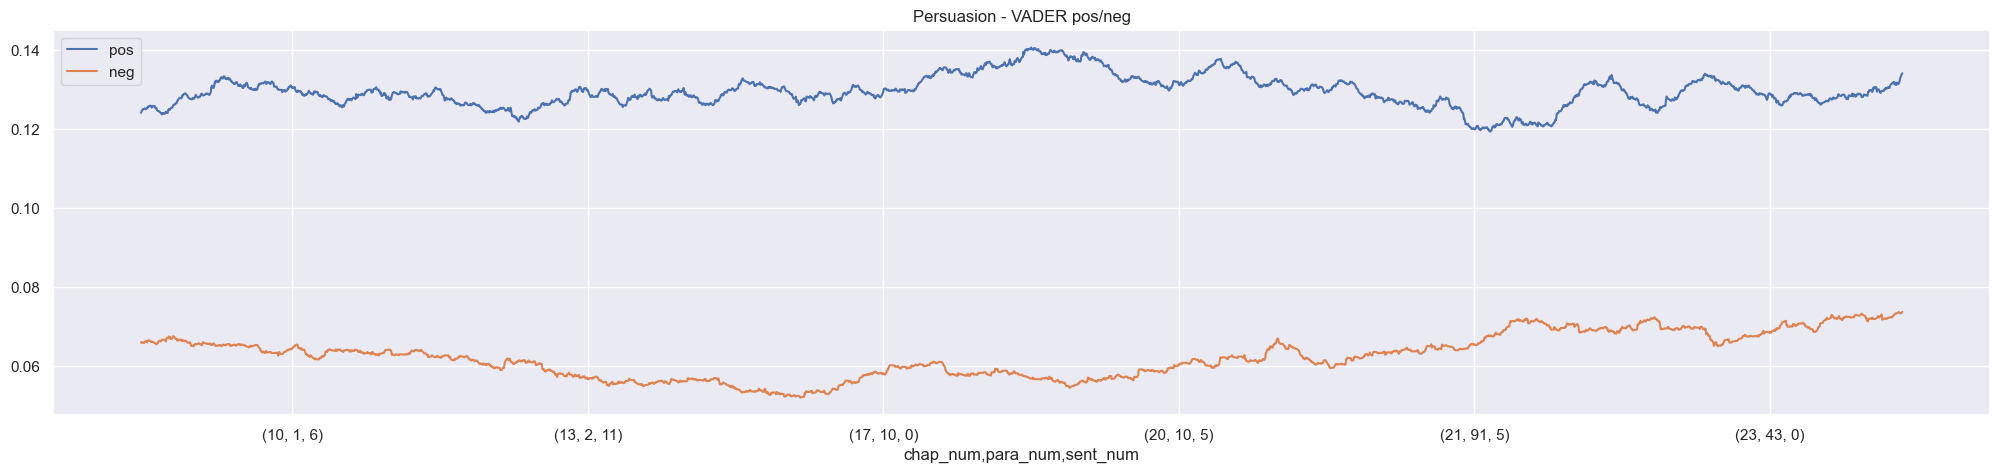

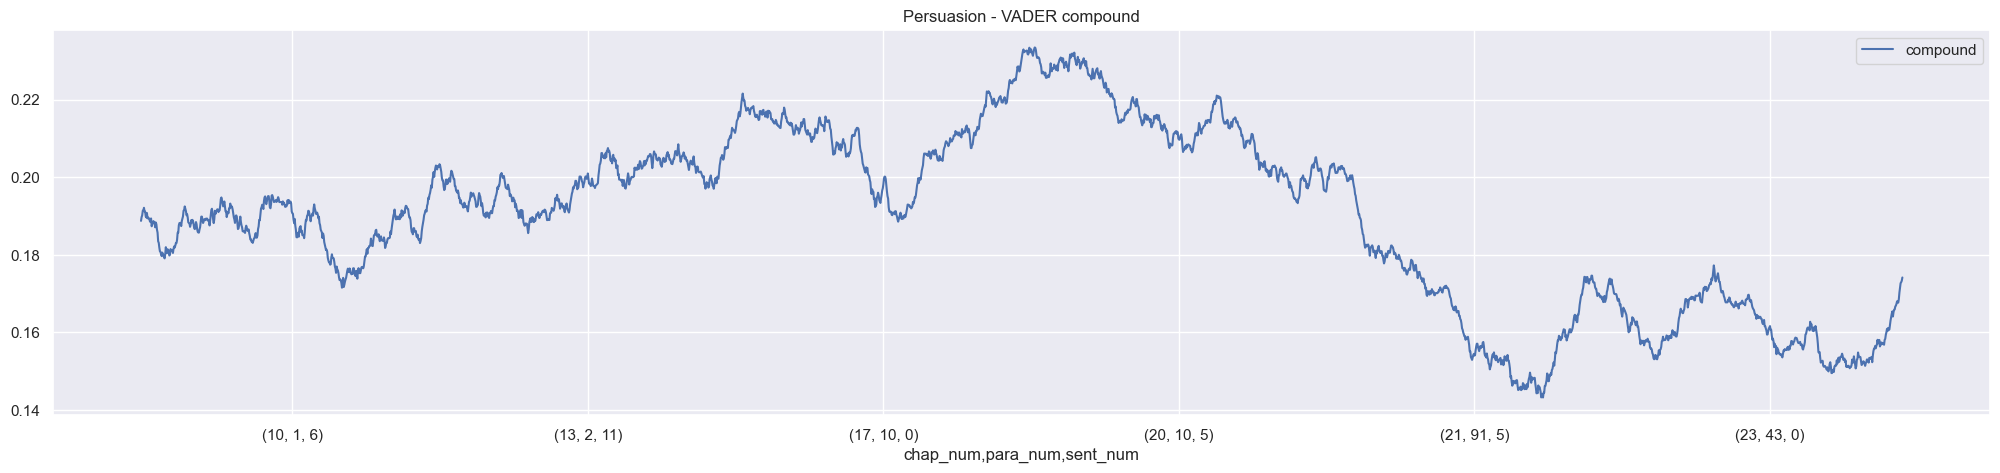

In [35]:
w = int(PERSUASION_vader.shape[0] / 5)
PERSUASION_vader[['pos','neg']].rolling(w).mean().plot(figsize=(25,5), title='Persuasion - VADER pos/neg')
PERSUASION_vader[['compound']].rolling(w).mean().plot(figsize=(25,5), title='Persuasion - VADER compound')